# CNN: 성인 남녀 얼굴 이미지 분류 - 이항 분류

In [2]:
import cv2, os, numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [3]:
image_dir = 'person_img'
xdata, ydata = [], []

# 남녀 구분 라벨 구하기 - 파일명에서 성별 추출   30_0_0_20170119195539771.jpg - split 함수

for file in os.listdir(image_dir):
    try:
        gender = int(file.split('_')[1])    # 0:male, 1:female
        img_path = os.path.join(image_dir, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (64, 64))     # 크기 축소
        xdata.append(img)
        ydata.append(gender)
    except:
        continue

print(xdata[0])
print(ydata[0])

xdata = np.array(xdata) / 255.0
ydata = np.array(ydata)


[[[ 16  35  26]
  [ 14  32  25]
  [ 12  30  24]
  ...
  [100 116 129]
  [103 119 131]
  [102 118 130]]

 [[ 19  37  30]
  [ 16  33  26]
  [ 13  30  26]
  ...
  [ 90 104 113]
  [ 92 106 115]
  [ 94 106 116]]

 [[ 23  40  35]
  [ 18  35  31]
  [ 14  31  28]
  ...
  [ 91 101 106]
  [ 94 105 109]
  [ 96 106 111]]

 ...

 [[117 134 135]
  [129 143 142]
  [134 144 143]
  ...
  [106 104 104]
  [ 92  96  95]
  [ 99 107 106]]

 [[119 137 138]
  [126 140 139]
  [122 132 130]
  ...
  [126 123 123]
  [125 129 128]
  [126 132 131]]

 [[105 123 124]
  [ 93 107 106]
  [106 116 114]
  ...
  [152 147 148]
  [108 107 107]
  [121 126 125]]]
0


In [4]:
# train / tset
import random


x_train, x_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(102, 64, 64, 3) (26, 64, 64, 3) (102,) (26,)


In [5]:
# model
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 31, 31, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 14, 14, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 12544)             0         
                                                                 
 dense (Dense)               (None, 128)               1

In [6]:
history = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=2)
loss, acc = model.evaluate(x_test, y_test)
print(f'test acc:{acc:.4f}, loss:{loss:.4f}')

Epoch 1/100
3/3 - 3s - loss: 0.9755 - accuracy: 0.6543 - val_loss: 0.6712 - val_accuracy: 0.5714 - 3s/epoch - 1s/step
Epoch 2/100
3/3 - 0s - loss: 0.6324 - accuracy: 0.6420 - val_loss: 0.5961 - val_accuracy: 0.7143 - 36ms/epoch - 12ms/step
Epoch 3/100
3/3 - 0s - loss: 0.5339 - accuracy: 0.7284 - val_loss: 0.6094 - val_accuracy: 0.7143 - 36ms/epoch - 12ms/step
Epoch 4/100
3/3 - 0s - loss: 0.4881 - accuracy: 0.7407 - val_loss: 0.6203 - val_accuracy: 0.6667 - 36ms/epoch - 12ms/step
Epoch 5/100
3/3 - 0s - loss: 0.4841 - accuracy: 0.8519 - val_loss: 0.6437 - val_accuracy: 0.6190 - 39ms/epoch - 13ms/step
Epoch 6/100
3/3 - 0s - loss: 0.4473 - accuracy: 0.7778 - val_loss: 0.6729 - val_accuracy: 0.6667 - 40ms/epoch - 13ms/step
Epoch 7/100
3/3 - 0s - loss: 0.4172 - accuracy: 0.8642 - val_loss: 0.6776 - val_accuracy: 0.6190 - 37ms/epoch - 12ms/step
Epoch 8/100
3/3 - 0s - loss: 0.3538 - accuracy: 0.8889 - val_loss: 0.7777 - val_accuracy: 0.6667 - 36ms/epoch - 12ms/step
Epoch 9/100
3/3 - 0s - loss:

# 예측

1/1 [==============================] - 0s 58ms/step
예측값:  [0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
실제값:  [1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1]


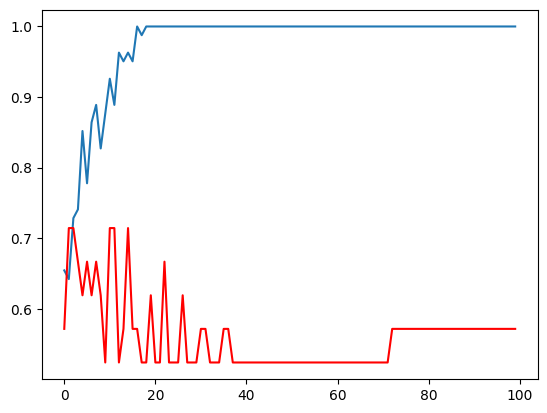

In [7]:
pred = model.predict(x_test)
print('예측값: ', (pred >= 0.5).astype(int).reshape(-1))
print('실제값: ', y_test)

import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], c='r', label='val acc')
plt.show()

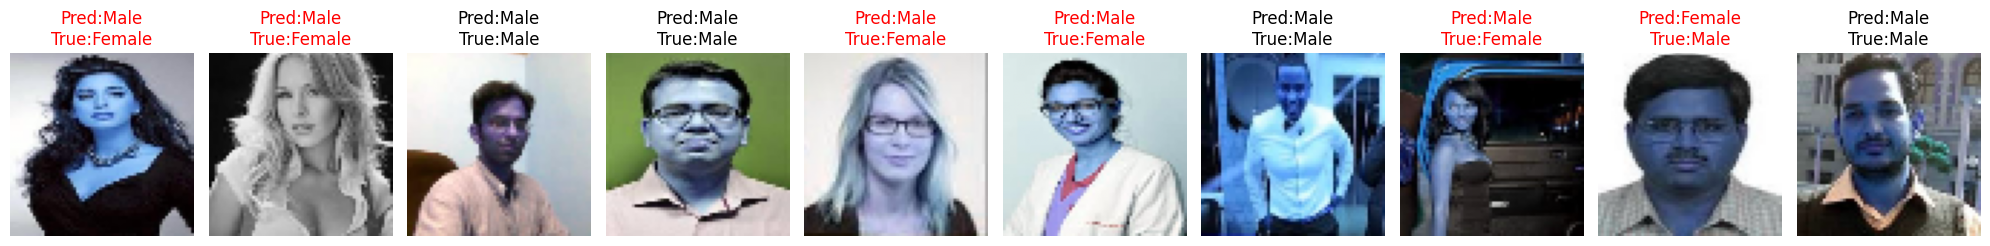

In [ ]:
pred_classes = (pred >= 0.5).astype(int).reshape(-1)
true_classes = y_test

plt.figure(figsize=(20, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i])

    # 예측값과 실제값 표시
    is_correct = pred_classes[i] == true_classes[i]
    label = 'Female' if true_classes[i] == 1 else 'Male'
    prediction = 'Female' if pred_classes[i] == 1 else 'Male'

    title_color = 'black' if is_correct else 'red'
    plt.title(f'Pred:{prediction}\nTrue:{label}',color=title_color)
    plt.axis('off')
    
plt.tight_layout()
plt.show()                                                                                                    